In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from tqdm.notebook import tqdm
warnings.filterwarnings('ignore')
%matplotlib inline

import tensorflow as tf
from keras.preprocessing.image import load_img
from keras.models import Sequential, Model
from keras.layers import Dense, Conv2D, Dropout, Flatten, MaxPooling2D, Input

## Load The Dataset

In [2]:
BASE_DIR =r"C:\Users\Sunil\Downloads\UTKFace\UTKFace"

In [3]:
# labels - age,gender,ethnicity

image_paths =[]
age_labels = []
gender_labels = []
for filename in tqdm(os.listdir(BASE_DIR)):
    image_path = os.path.join(BASE_DIR, filename)
    temp = filename.split('_')
    age = int(temp[0])
    gender = int(temp[1])
    image_paths.append(image_path)
    age_labels.append(age)
    gender_labels.append(gender)
    

  0%|          | 0/23708 [00:00<?, ?it/s]

In [4]:
df = pd.DataFrame()
df['image'], df['age'], df['gender'] = image_paths,age_labels, gender_labels
df.head()

,image,age,gender
0,C:\Users\Sunil\Downloads\UTKFace\UTKFace\100_0...,100,0
1,C:\Users\Sunil\Downloads\UTKFace\UTKFace\100_0...,100,0
2,C:\Users\Sunil\Downloads\UTKFace\UTKFace\100_1...,100,1
3,C:\Users\Sunil\Downloads\UTKFace\UTKFace\100_1...,100,1
4,C:\Users\Sunil\Downloads\UTKFace\UTKFace\100_1...,100,1


In [5]:
# Map labels for gender
gender_dict = {0:'Male', 1:'Female'}

## Exploratary Data Analysis

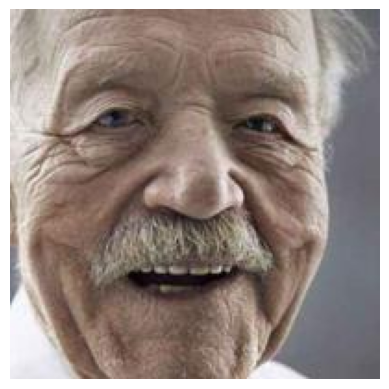

In [6]:
from PIL import Image
img = Image.open(df['image'][0])
plt.axis('off')
plt.imshow(img);

<Axes: xlabel='age', ylabel='Density'>

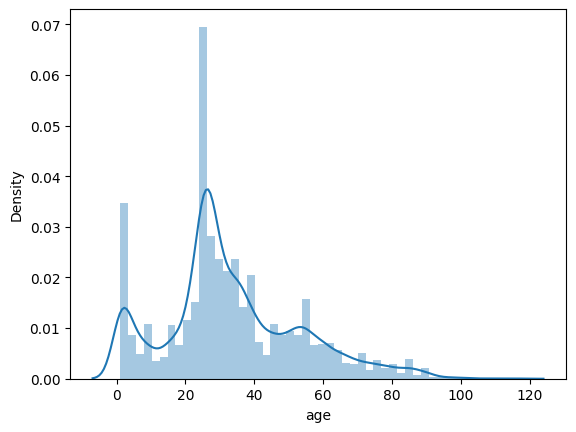

In [7]:
sns.distplot(df['age'])

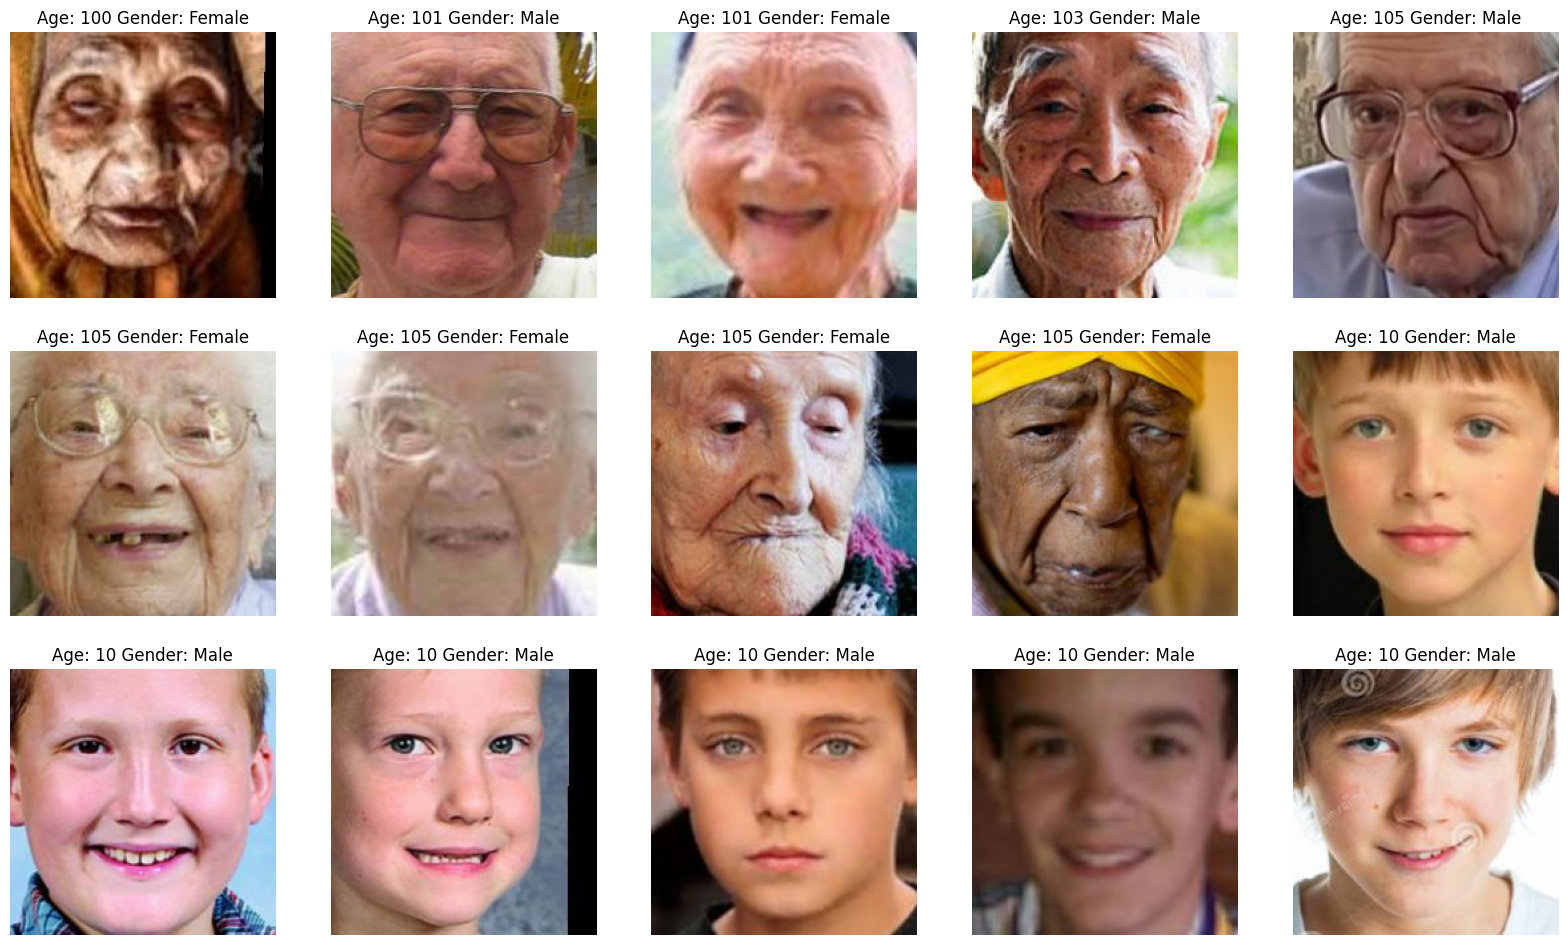

In [8]:
# To display grid of images
plt.figure(figsize = (20, 20))
files = df.iloc[10:25]

for index, file,age, gender in files.itertuples():
    plt.subplot(5, 5, index+1)
    img = load_img(file)
    img = np.array(img)
    plt.imshow(img)
    plt.title(f"Age: {age} Gender: {gender_dict[gender]}")
    plt.axis('off')

## Feature Extraction

In [9]:
def extract_features(images):
    features = []
    for image in tqdm(images):
        img = load_img(image, color_mode ="grayscale")
        img = img.resize((128,128))
        img = np.array(img)
        features.append(img)

    features = np.array(features)
    features = features.reshape(len(features), 128, 128, 1)
    return features  

In [10]:
X = extract_features(df['image'])

  0%|          | 0/23708 [00:00<?, ?it/s]

In [11]:
X.shape

(23708, 128, 128, 1)

In [12]:
# normalise the images
X = X/255.0

In [13]:
y_gender = np.array(df['gender'])
y_age = np.array(df['age'])

In [14]:
input_shape = (128, 128, 1)

## Model Creation

In [15]:
inputs = Input((input_shape))

conv_1 = Conv2D(32, kernel_size=(3,3), activation = 'relu')(inputs)
maxp_1 = MaxPooling2D(pool_size=(2,2))(conv_1)
conv_2 = Conv2D(64, kernel_size=(3,3), activation = 'relu')(maxp_1)
maxp_2 = MaxPooling2D(pool_size=(2,2))(conv_2)
conv_3 = Conv2D(128, kernel_size=(3,3), activation = 'relu')(maxp_2)
maxp_3 = MaxPooling2D(pool_size=(2,2))(conv_3)
conv_4 = Conv2D(256, kernel_size=(3,3), activation = 'relu')(maxp_3)
maxp_4 = MaxPooling2D(pool_size=(2,2))(conv_4)

flatten = Flatten() (maxp_4)

#fully connected layers
dense_1 = Dense(256, activation ='relu')(flatten)
dense_2 = Dense(256, activation ='relu')(flatten)

dropout_1 = Dropout(0.3)(dense_1)
dropout_2 = Dropout(0.3)(dense_2)

output_1 = Dense(1, activation='sigmoid', name='gender_out')(dropout_1)
output_2 = Dense(1, activation='relu', name='age_out')(dropout_2)

model = Model(inputs=inputs, outputs=[output_1, output_2])

model.compile(
    optimizer='adam',
    loss=['binary_crossentropy', 'mae'],  # gender + age
    metrics=['accuracy', 'mae']           # one metric per output
)

In [16]:
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 128, 128, 1)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d (Conv2D)               │ (None, 126, 126, 32)      │             320 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d (MaxPooling2D)  │ (None, 63, 63, 32)        │               0 │ conv2d[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_1 (Conv2D)             │ (None, 61, 61, 64)        │          18,496 │ max_pooling2d[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_1               │ (None, 30, 30, 64)        │               0 │ conv2d_1[0][0]             │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_2 (Conv2D)             │ (None, 28, 28, 128)       │          73,856 │ max_pooling2d_1[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_2               │ (None, 14, 14, 128)       │               0 │ conv2d_2[0][0]             │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_3 (Conv2D)             │ (None, 12, 12, 256)       │         295,168 │ max_pooling2d_2[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_3               │ (None, 6, 6, 256)         │               0 │ conv2d_3[0][0]             │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten (Flatten)             │ (None, 9216)              │               0 │ max_pooling2d_3[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 256)               │       2,359,552 │ flatten[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 256)               │       2,359,552 │ flatten[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 256)               │               0 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 256)               │               0 │ dense_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ gender_out (Dense)            │ (None, 1)                 │             257 │ dropout[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ age_out (Dense)               │ (None, 1)                 │             25

 Total params: 5,107,458 (19.48 MB)

 Trainable params: 5,107,458 (19.48 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
#plot the model
#from tensorflow.keras.utils import plot_model
#plot_model(model)

In [18]:
# Train model
history = model.fit(x=X, y=[y_gender, y_age], batch_size=32, epochs=30, validation_split=0.2)

Epoch 1/30
593/593 ━━━━━━━━━━━━━━━━━━━━ 1739s 3s/step - age_out_loss: 10.0438 - age_out_mae: 10.0450 - gender_out_accuracy: 0.5602 - gender_out_loss: 0.6702 - loss: 10.7154 - val_age_out_loss: 29.2300 - val_age_out_mae: 29.3321 - val_gender_out_accuracy: 0.7242 - val_gender_out_loss: 0.5494 - val_loss: 29.8828
Epoch 2/30
593/593 ━━━━━━━━━━━━━━━━━━━━ 431s 728ms/step - age_out_loss: 7.5279 - age_out_mae: 7.5283 - gender_out_accuracy: 0.7987 - gender_out_loss: 0.4279 - loss: 7.9562 - val_age_out_loss: 29.5223 - val_age_out_mae: 29.6480 - val_gender_out_accuracy: 0.7733 - val_gender_out_loss: 0.4863 - val_loss: 30.1356
Epoch 3/30
593/593 ━━━━━━━━━━━━━━━━━━━━ 5190s 9s/step - age_out_loss: 6.7424 - age_out_mae: 6.7433 - gender_out_accuracy: 0.8405 - gender_out_loss: 0.3503 - loss: 7.0937 - val_age_out_loss: 28.8460 - val_age_out_mae: 28.9676 - val_gender_out_accuracy: 0.7777 - val_gender_out_loss: 0.4952 - val_loss: 29.4632
Epoch 4/30
593/593 ━━━━━━━━━━━━━━━━━━━━ 484s 726ms/step - age_out_lo

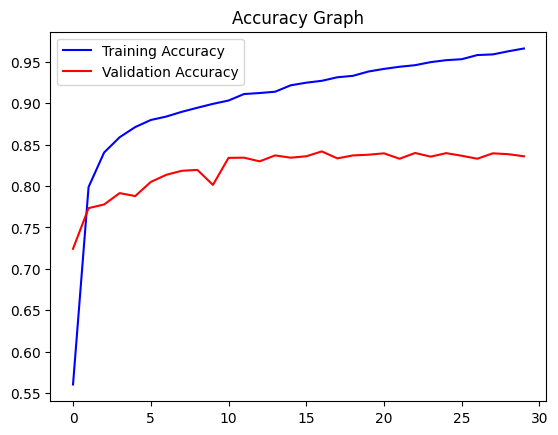

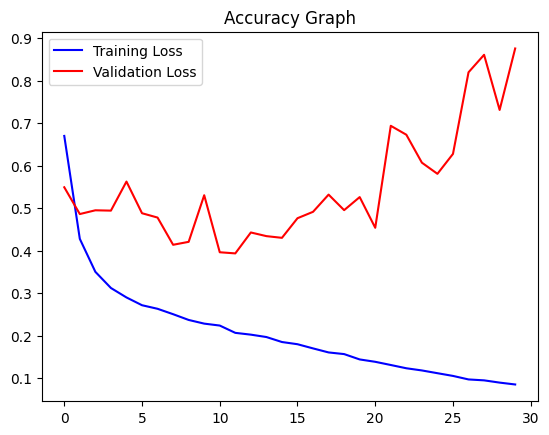

In [21]:
# Plot results for gender

acc = history.history['gender_out_accuracy']
val_acc = history.history['val_gender_out_accuracy']
epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation Accuracy')
plt.title('Accuracy Graph')
plt.legend()
plt.figure()

loss = history.history['gender_out_loss']
val_loss = history.history['val_gender_out_loss']

plt.plot(epochs, loss, 'b', label='Training Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.title('Accuracy Graph')
plt.legend()
plt.show()

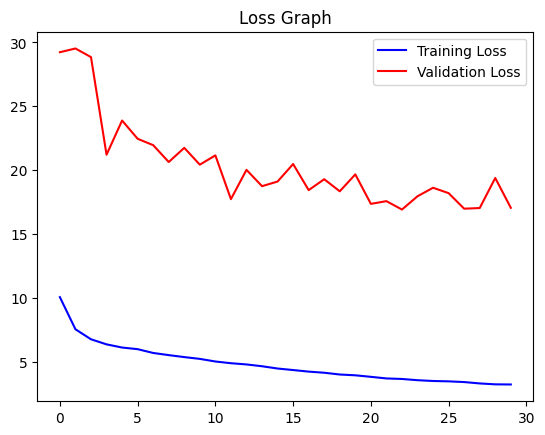

In [22]:
# Plot results for age

loss = history.history['age_out_loss']
val_loss = history.history['val_age_out_loss']
epochs = range(len(loss))

plt.plot(epochs, loss, 'b', label='Training Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.title('Loss Graph')
plt.legend()
plt.show()

## Prediction with Test Data

Original gender: Male Original Age: 10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step
Predicted Gender: Male Predicted Age: 13


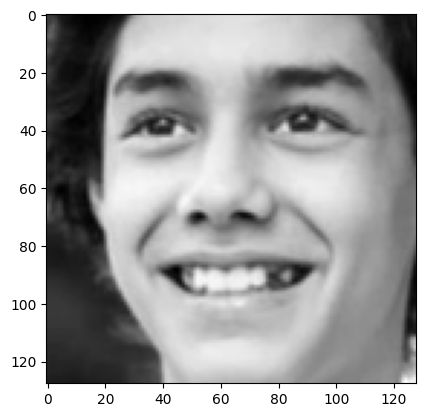

In [23]:
image_index = 100
print("Original gender:", gender_dict[y_gender[image_index]], "Original Age:", y_age[image_index])
# predict from model
pred = model.predict(X[image_index].reshape(1, 128, 128,1))
pred_gender = gender_dict[round(pred[0][0][0])]
pred_age = round(pred[1][0][0])
print("Predicted Gender:", pred_gender, "Predicted Age:", pred_age)
plt.imshow(X[image_index].reshape(128, 128), cmap = 'gray')